In [89]:
from sklearn.cluster import KMeans
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import MinMaxScaler

In [90]:
pwd

'C:\\Users\\ARPIT DUBEY\\Machine Learning'

In [91]:
df = pd.read_csv('C:\\Users\\ARPIT DUBEY\\income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


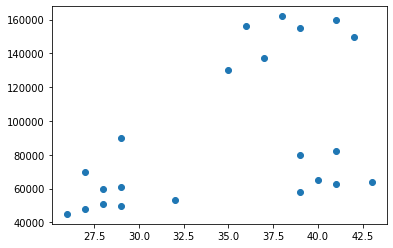

In [92]:
plt.scatter(df['Age'],df['Income($)'])

In [93]:
km = KMeans(n_clusters=3)
km

KMeans(n_clusters=3)

In [94]:
y_predicted=km.fit_predict(df[['Age','Income($)']])
y_predicted

array([2, 0, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2])

In [95]:
#three cluster label as 0,1,2
df['cluster'] = y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,2
1,Michael,29,90000,0
2,Mohan,29,61000,2
3,Ismail,28,60000,2
4,Kory,42,150000,1


C:\Users\ARPIT DUBEY\AppData\Local\Temp\ipykernel_12056\4050211410.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


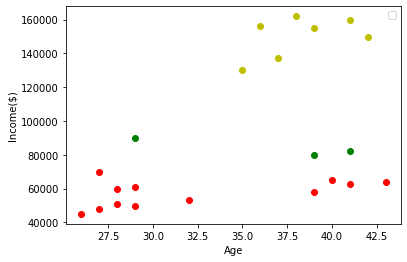

In [96]:
#lets plot this on scatter plot
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]

plt.scatter(df1.Age,df1['Income($)'],color ='g')
plt.scatter(df2.Age,df2['Income($)'],color ='y')
plt.scatter(df3.Age,df3['Income($)'],color ='r')

plt.xlabel('Age')
plt.ylabel('Income($)')
plt.legend()

In [97]:
# as in the plot you can see there is still impurity present in cluster=0 and cluster=2.
#this is because , we dont have proper scaling
# y-axis starts from 40000 and goes to 160000 whereas x-axis is having a difference of just 20 
# As it seems uneven 
#we Solve this through MinMaxScaler()

In [98]:
# first correcting scaling of y-axis i.e Income($)
scaler = MinMaxScaler()
scaler.fit(df[['Income($)']])
df['Income($)']=scaler.fit_transform(df[['Income($)']])
df.head()

,Name,Age,Income($),cluster
0,Rob,27,0.213675,2
1,Michael,29,0.384615,0
2,Mohan,29,0.136752,2
3,Ismail,28,0.128205,2
4,Kory,42,0.897436,1


In [99]:
# Now , x-axis i.e Age
scaler.fit(df[['Age']])
df['Age'] = scaler.fit_transform(df[['Age']])
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,2
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,2
3,Ismail,0.117647,0.128205,2
4,Kory,0.941176,0.897436,1


In [100]:
#now doing the same step 
km = KMeans(n_clusters=3)
km

KMeans(n_clusters=3)

In [101]:
y_predicted = km.fit_predict(df[['Age']],df[['Income($)']])
y_predicted

array([0, 0, 0, 0, 2, 1, 2, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 1, 2, 1])

In [102]:
df['cluster'] = y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,2


In [103]:
km.cluster_centers_

array([[0.1372549 ],
       [0.68067227],
       [0.90196078]])

TypeError: scatter() missing 1 required positional argument: 'y'

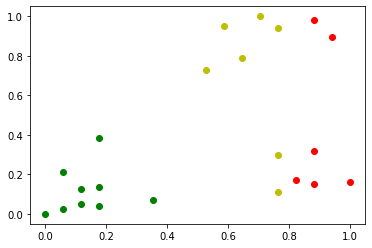

In [106]:
#lets plot this on scatter plot
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]

plt.scatter(df1.Age,df1['Income($)'],color ='g')
plt.scatter(df2.Age,df2['Income($)'],color ='y')
plt.scatter(df3.Age,df3['Income($)'],color ='r')

plt.scatter(km.cluster_centers_[:,0],color='purple',marker='+',label='centroid')
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.legend()

In [108]:
#Elbow Algorithm!!
k_rng = range(1,10)
sse=[]
for k in k_rng:
    km = KMeans(n_clusters =k)
    km.fit(df[['Age','Income($)']])
    sse.append(km.inertia_)    

In [109]:
sse

[5.434011511988179,
 2.091136388699078,
 0.4750783498553096,
 0.36986589192348335,
 0.2798062931046179,
 0.22443334487241423,
 0.18833966929558865,
 0.15065740983583237,
 0.12152347379331081]

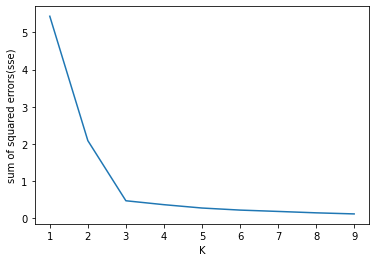

In [110]:
plt.xlabel('K')
plt.ylabel('sum of squared errors(sse)')
plt.plot(k_rng,sse)

In [ ]:
#through above prblm, k=3 is the best no. of clusters to be used !!